In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from pyproj import Geod
from scipy.spatial import cKDTree


In [2]:
## Drone data
sizes = pd.read_csv('rawdata/territory_sizes_2023.txt', sep='	')
sizes = sizes.rename(columns={'Territory': 'territory_id', 'sizes': 'size'})
ninetyfive_percentile = sizes['size'].quantile(0.95)

locations2023 = pd.read_csv('rawdata/territories_2023.txt', header=None, names=['territory_id', 'longitude', 'latitude', 'altitude', 'blank'])
locations2023 = locations2023.loc[:, ['territory_id', 'longitude', 'latitude']]
locations2023 = locations2023.merge(sizes[['territory_id', 'size']], on='territory_id', how='left')

locations2024 = pd.read_csv('rawdata/territories_2024.txt', header=None, names=['territory_id', 'longitude', 'latitude', 'altitude', 'blank'])
locations2024 = locations2024.loc[:, ['territory_id', 'longitude', 'latitude']]

geod = Geod(ellps='WGS84')

In [3]:
## Match 2024 territories to 2023 territories using longitude/latitude
xy_2023 = locations2023[['longitude', 'latitude']].to_numpy()
xy_2024 = locations2024[['longitude', 'latitude']].to_numpy()

tree_2023 = cKDTree(xy_2023)
_, nearest_2023_row = tree_2023.query(xy_2024, k=1)

nearest_distance_m = []

for row_2024, row_2023 in enumerate(nearest_2023_row):
    _, _, distance_m = geod.inv(locations2024.loc[row_2024, 'longitude'], locations2024.loc[row_2024, 'latitude'],
                                locations2023.loc[row_2023, 'longitude'], locations2023.loc[row_2023, 'latitude'])

    nearest_distance_m.append(distance_m)

correspondences = pd.DataFrame({
    'territory_id_2024': locations2024['territory_id'].astype(int),
    'longitude_2024': locations2024['longitude'],
    'latitude_2024': locations2024['latitude'],
    'nearest_2023_row': nearest_2023_row,
    'territory_id_2023': locations2023.iloc[nearest_2023_row]['territory_id'].astype(int).to_numpy(),
    'longitude_2023': locations2023.iloc[nearest_2023_row]['longitude'].to_numpy(),
    'latitude_2023': locations2023.iloc[nearest_2023_row]['latitude'].to_numpy(),
    'distance_m': nearest_distance_m
})

## If multiple 2024 territories claim the same 2023 territory, keep the closest one
correspondences = correspondences.sort_values('distance_m').drop_duplicates('territory_id_2023').sort_values('territory_id_2023').reset_index(drop=True)
correspondences.head()


,territory_id_2024,longitude_2024,latitude_2024,nearest_2023_row,territory_id_2023,longitude_2023,latitude_2023,distance_m
0,26,74.436963,27.800044,0,1,74.436945,27.800021,3.105089
1,58,74.436612,27.799956,2,3,74.436602,27.799934,2.584933
2,59,74.436796,27.799803,3,4,74.436794,27.799810,0.766251
3,166,74.437142,27.799795,4,5,74.437163,27.799771,3.299700
4,165,74.437060,27.799882,5,6,74.437010,27.799881,4.956709


In [4]:
## Mark correspondences as reused if the 2024 territory falls within the reuse radius
correspondences['reused'] = (correspondences['distance_m'] <= ninetyfive_percentile).astype(int)

## Add reuse status back to locations2023
locations2023['reused'] = locations2023['territory_id'].isin(correspondences.loc[correspondences['reused'] == 1, 'territory_id_2023']).astype(int)

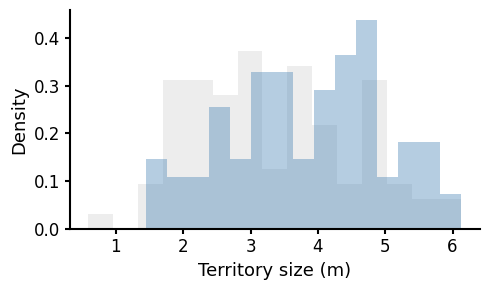

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))

sizes_not_reused = locations2023.loc[locations2023['reused'] == 0, 'size']
sizes_reused = locations2023.loc[locations2023['reused'] == 1, 'size']

# Histograms
ax.hist(sizes_not_reused, bins=15, density=True, color='lightgrey', alpha=0.4)
ax.hist(sizes_reused, bins=15, density=True, color='steelblue', alpha=0.4)

# KDEs
xs = np.linspace(locations2023['size'].min(), locations2023['size'].max(), 300)

kde_not_reused = scipy.stats.gaussian_kde(sizes_not_reused)
kde_reused = scipy.stats.gaussian_kde(sizes_reused)

# ax.plot(xs, kde_not_reused(xs), color='black', linewidth=3)
# ax.plot(xs, kde_reused(xs), color='steelblue', linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Territory size (m)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)

plt.tight_layout()